# Delivery Time Prediction Using Machine Learning

## Business Objective
The objective of this project is to analyze operational factors that affect food delivery time and build predictive models to estimate delivery duration.

Understanding these factors can help logistics and quick commerce platforms improve delivery efficiency and customer satisfaction.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("/content/Food_Delivery_Times.csv")

df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [4]:
df.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


In [5]:
df = df.dropna()

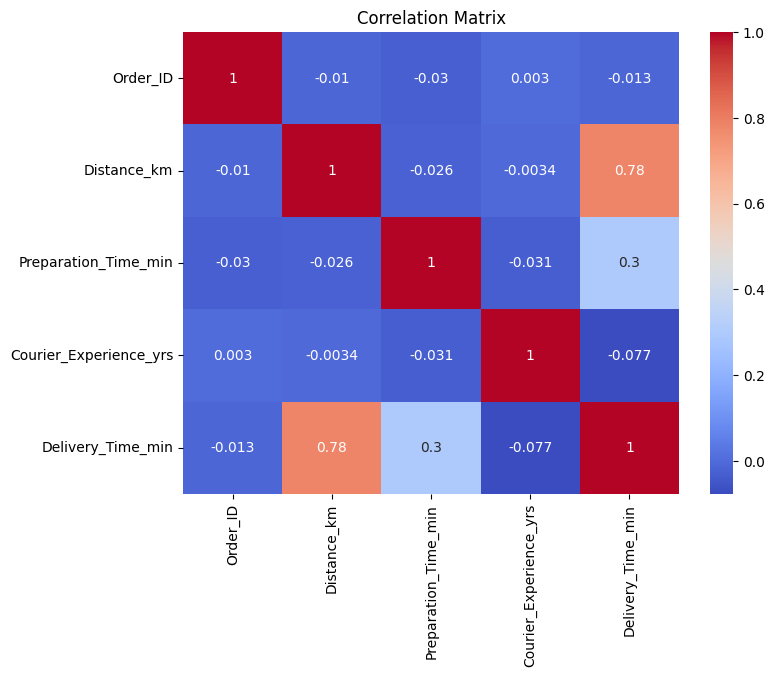

In [7]:
numeric_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [9]:
df = df.drop("Order_ID", axis=1)

In [10]:
df = pd.get_dummies(df, drop_first=True)

In [11]:
X = df.drop("Delivery_Time_min", axis=1)

y = df["Delivery_Time_min"]

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Linear Regression Results")

print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2 Score:", r2_score(y_test, y_pred_lr))

Linear Regression Results
MAE: 5.319617041145194
RMSE: 8.27331673278112
R2 Score: 0.83253145823043


In [15]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(random_state=42)

tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

In [16]:
print("Decision Tree Results")

print("MAE:", mean_absolute_error(y_test, y_pred_tree))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_tree)))
print("R2 Score:", r2_score(y_test, y_pred_tree))

Decision Tree Results
MAE: 9.971751412429379
RMSE: 13.90504521696624
R2 Score: 0.5269372549062483


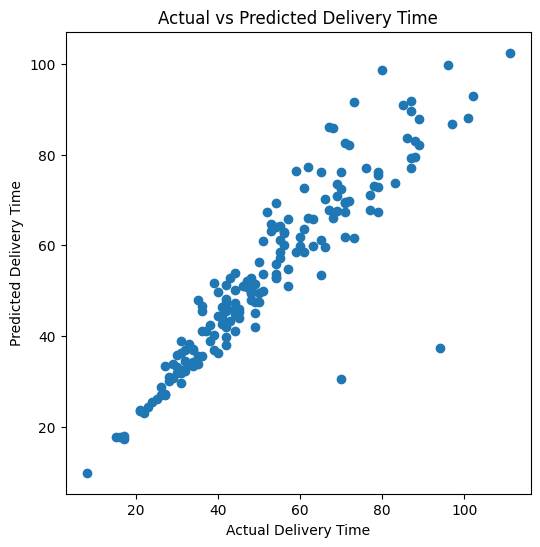

In [17]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_lr)

plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")

plt.title("Actual vs Predicted Delivery Time")

plt.show()

**Key Insights**

Delivery time is influenced by factors such as distance, preparation time,
traffic conditions, and courier experience.

The decision tree model captures nonlinear relationships better,
while linear regression provides a simple baseline model.

**Conclusion**

Predicting delivery time helps logistics and quick commerce platforms
improve operational efficiency and customer satisfaction.
Machine learning models can assist in estimating delivery duration
and optimizing delivery planning.